In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
from data import load_data

plt.rcParams['font.family'] = 'DejaVu Sans Mono'

df = load_data()
genes = [el for el in df.columns if el.startswith('rs')]

df_coded = df.copy()[genes]
mask_nontrivial = []
for gene in genes:
    col = df[gene]
    cnt_a, cnt_c, cnt_g, cnt_t = [col.str.count(char) for char in 'ACGT']
    df_coded[gene] = (cnt_a*27 + cnt_c*9 + cnt_g*3 + cnt_t).astype(np.float32)
    mask_nontrivial += [cnt.nunique() for cnt in [cnt_a, cnt_c, cnt_g, cnt_t]]
mask_nontrivial = np.array(mask_nontrivial) > 1

df_oh = pd.get_dummies(df.iloc[:, 3:])

In [81]:
from scipy.spatial import distance_matrix

dist_mat = distance_matrix(df_oh, df_oh)

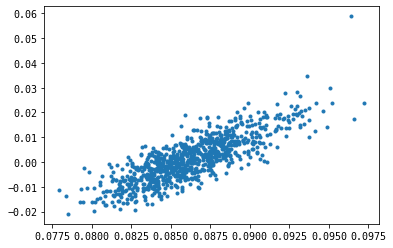

In [124]:
scale = 1e2

mask = df['Geographic region'] == 'SWA'
weighting = np.linalg.lstsq(
    np.exp(-dist_mat[mask][:, mask] / scale), np.ones((mask.sum(), )), rcond=None
)[0]

df_part = df_oh[mask].values
plt.scatter(
    np.linalg.norm(df_part - np.mean(df_part, axis=0, keepdims=True), axis=1) / scale, 
    weighting,
    s=9.
)
plt.show(); plt.close()

In [117]:
mask_new = df['Geographic region'] == 'NEA'
mask_new = mask_new & (np.cumsum(mask_new) < 21)
x = df_oh[mask_new]

z_11 = np.exp(- dist_mat[mask][:, mask] / scale)
b = np.exp(- distance_matrix(df_oh[mask_new], df_oh[mask]) / scale)

ws = []
for i in range(b.shape[0]):
    print(i, end=' ')
    a_upper = np.concatenate([z_11, b[i:i+1].T], axis=1)
    a_lower = np.concatenate([b[i:i+1], np.ones((1, 1))], axis=1)
    a = np.concatenate([a_upper, a_lower], axis=0)
    w = np.linalg.lstsq(a, np.ones(a.shape[0]), rcond=None)[0]
    ws.append(w)
ws = np.array(ws)

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 

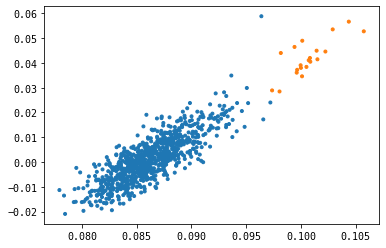

In [118]:
df_part_new = np.concatenate([df_part, df_oh[mask_new].values], axis=0)
plt.scatter(
    np.linalg.norm(df_part_new - np.mean(df_part, axis=0, keepdims=True), axis=1) / scale, 
    np.concatenate([weighting, ws[:, -1]], axis=0),
    s=9.,
    c=['C0']*weighting.shape[0] + ['C1']*ws.shape[0]
)
plt.show(); plt.close()

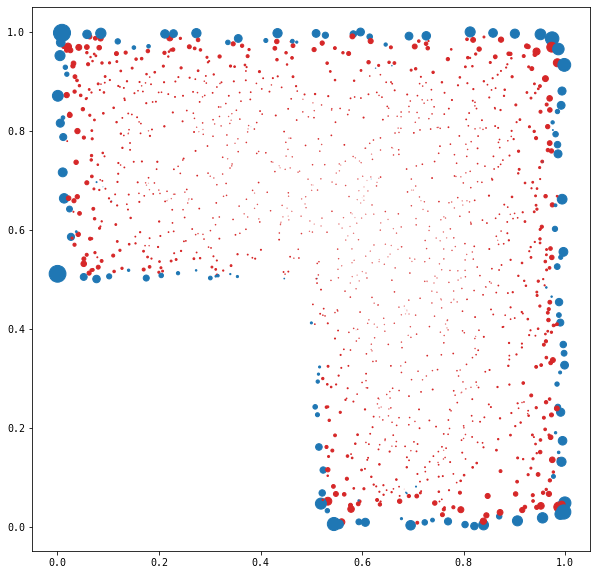

In [40]:
from scipy.spatial import distance_matrix

np.random.seed(42)
pts = np.random.uniform(size=(2000, 2))
pts = pts[(pts[:, 0] >= 0.5) | (pts[:, 1] >= 0.5)]
dist_mat = distance_matrix(pts, pts)
w, *_  = np.linalg.lstsq(np.exp(-dist_mat), np.ones(pts.shape[0]), rcond=None)

plt.figure(figsize=(10, 10))
plt.scatter(
    *pts.T, s=1e3*np.abs(w),
    c=['C0' if el>=0 else 'C3' for el in w]
)
plt.show(); plt.close()